In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [4]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [5]:
# Scaling the features

scaler = StandardScaler()
X_scale = scaler.fit_transform(df)

In [6]:
inertia = []
k_range = range(1, 11)

In [7]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scale)
    inertia.append(kmeans.inertia_)

In [8]:
inertia

[1000.0,
 297.8954141051723,
 11.57548472310498,
 9.752067977356841,
 8.257175272446284,
 6.9175773204168,
 6.334755391595291,
 5.704177177901429,
 5.060234133532076,
 4.762361898130396]

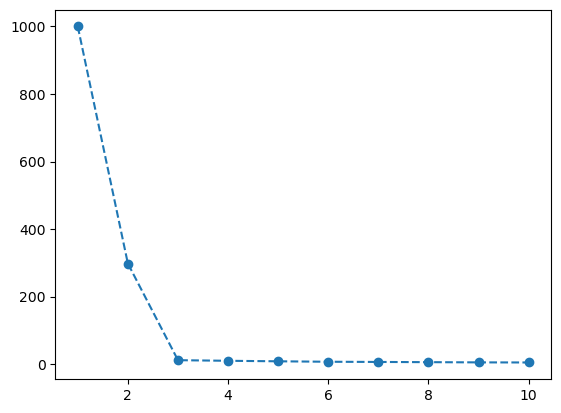

In [9]:
plt.plot(k_range, inertia, 'o--')

In [23]:
kmeans_final = KMeans(n_clusters=6, random_state=42)

In [24]:
cluster_label = kmeans_final.fit_predict(X_scale)

In [25]:
cluster_label

array([5, 3, 0, 4, 0, 0, 5, 0, 3, 1, 3, 2, 2, 2, 0, 0, 4, 1, 1, 4, 3, 2,
       0, 5, 1, 0, 3, 5, 1, 2, 0, 2, 4, 4, 0, 3, 3, 3, 1, 5, 3, 2, 4, 2,
       2, 0, 3, 0, 3, 1, 1, 4, 1, 5, 0, 4, 2, 1, 0, 1, 1, 2, 3, 5, 3, 1,
       0, 5, 2, 0, 0, 0, 0, 5, 4, 1, 2, 3, 2, 4, 5, 2, 3, 2, 1, 1, 1, 1,
       3, 2, 5, 0, 4, 0, 0, 5, 2, 4, 2, 5, 3, 2, 2, 1, 5, 2, 4, 1, 4, 1,
       1, 1, 1, 5, 5, 3, 4, 1, 3, 1, 2, 2, 3, 3, 5, 0, 4, 3, 1, 5, 5, 0,
       3, 5, 0, 1, 5, 1, 3, 4, 5, 5, 0, 3, 5, 1, 1, 4, 2, 4, 3, 1, 3, 3,
       2, 1, 2, 5, 0, 3, 5, 1, 2, 2, 1, 4, 4, 0, 1, 1, 5, 2, 2, 1, 5, 4,
       4, 3, 0, 0, 2, 5, 2, 2, 5, 1, 2, 0, 2, 5, 1, 1, 5, 1, 4, 0, 2, 2,
       1, 0, 2, 2, 5, 1, 3, 5, 3, 4, 2, 1, 5, 0, 5, 4, 2, 1, 2, 5, 2, 0,
       3, 4, 1, 4, 3, 2, 4, 5, 3, 3, 3, 3, 4, 1, 5, 1, 2, 0, 2, 0, 3, 3,
       4, 4, 5, 1, 0, 4, 2, 3, 2, 2, 4, 2, 3, 4, 1, 4, 5, 4, 2, 2, 1, 4,
       3, 0, 0, 4, 0, 3, 2, 4, 0, 5, 4, 4, 4, 2, 1, 1, 2, 3, 2, 4, 1, 2,
       0, 5, 3, 0, 5, 4, 4, 2, 1, 4, 5, 3, 0, 2, 0,

In [26]:
 df.columns

Index(['Feature_1', 'Feature_2', 'cluster'], dtype='object')

In [27]:
df['cluster'] = cluster_label

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

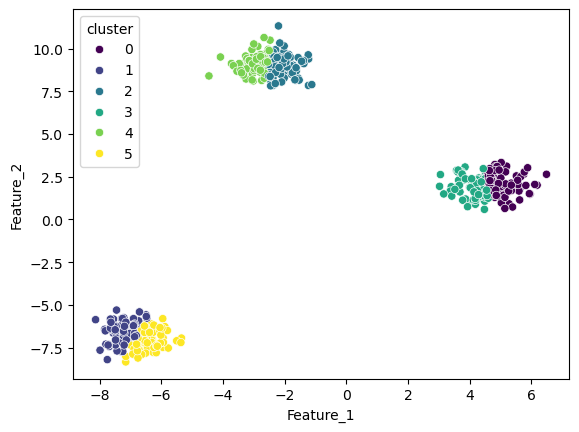

In [28]:
sns.scatterplot(x='Feature_1', y='Feature_2', hue='cluster', palette='viridis', data=df)

# DBSCAN

In [29]:
from sklearn.datasets import make_moons

In [30]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [35]:
from sklearn.cluster import DBSCAN

In [36]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [37]:
x_scaler = scaler.fit_transform(df)

### K-Means for understanding about why used DBSCAN

In [53]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_label = kmeans.fit_predict(x_scaler)

In [54]:
df.columns

Index(['Feature_1', 'Feature_2', 'kmeans_cluster'], dtype='object')

In [55]:
df['kmeans_cluster'] = kmeans_label

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

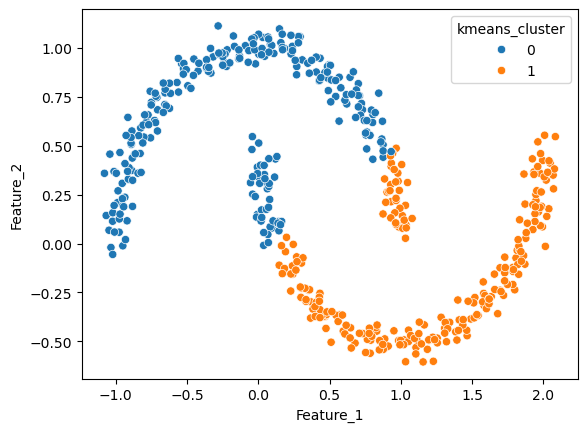

In [56]:
sns.scatterplot(x='Feature_1', y='Feature_2', hue='kmeans_cluster', data=df)

### Actually DBSCAN used

In [97]:
dbscan = DBSCAN(eps=0.4, min_samples=5)
dbscan_label = dbscan.fit_predict(x_scaler)

In [98]:
df['dbscan_cluster'] = dbscan_label

In [99]:
df.columns

Index(['Feature_1', 'Feature_2', 'kmeans_cluster', 'dbscan_cluster'], dtype='object')

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

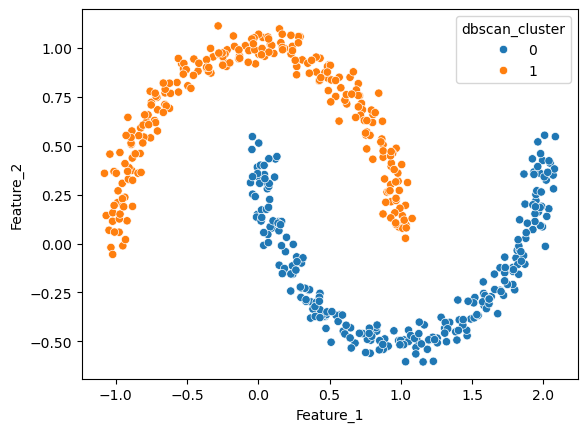

In [100]:
sns.scatterplot(x='Feature_1', y='Feature_2', hue='dbscan_cluster', data=df)